# **Implementación en Google Colab (50%)**

Desarrolle un cuaderno de Google Colab en Python que permita comparar LDA y QDA utilizando un conjunto de datos de clasificación.

NOMBRE: JUNIOR ALEXANDER FRANCO VERA

In [1]:
# IMPORTACIÓN DE LIBRERÍAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import (confusion_matrix,ConfusionMatrixDisplay,classification_report,accuracy_score,precision_score,recall_score, f1_score)

In [2]:
# CARGA DEL DATASET

wine = load_wine()

X = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

y = pd.Series(
    wine.target,
    name="Clase"
)

df = X.copy()
df["Clase"] = y

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Clase
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


# **1. Descripción del conjunto de datos**

---








origen del dataset:

El conjunto de datos utilizado corresponde al Wine Dataset, el cual forma parte de la biblioteca Scikit-learn. Este dataset contiene mediciones químicas de vinos cultivados en una misma región de Italia y es ampliamente utilizado para evaluar algoritmos de clasificación supervisada.

In [3]:
# Número de observaciones.
df.shape

(178, 14)

In [4]:
# variables predictoras.
X.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')

In [5]:
# Variable objetivo.
y.value_counts()

,count
Clase,
1,71
0,59
2,48


In [6]:
# cantidad de clases.

print('Número de clases:', y.nunique())

Número de clases: 3


# 2. Exploración de los datos

Realice un análisis exploratorio que incluya, como mínimo:

dimensiones del conjunto de datos;

tipos de variables;

valores faltantes;

estadísticas descriptivas;

distribución de clases.



In [7]:
# dimensiones del conjunto de datos.
df.shape


(178, 14)

In [8]:
# tipos de variables

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  Clase

In [9]:
# Valores faltantes
df.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


In [10]:
# estadísticas descriptivas.

df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Clase
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [11]:
# distribución de clases.
df['Clase'].value_counts()

,count
Clase,
1,71
0,59
2,48


# 3. Visualización
Incluya al menos tres visualizaciones apropiadas para
comprender el comportamiento de los datos, por ejemplo:

histogramas;

diagramas de dispersión;

mapa de correlaciones;

boxplots.


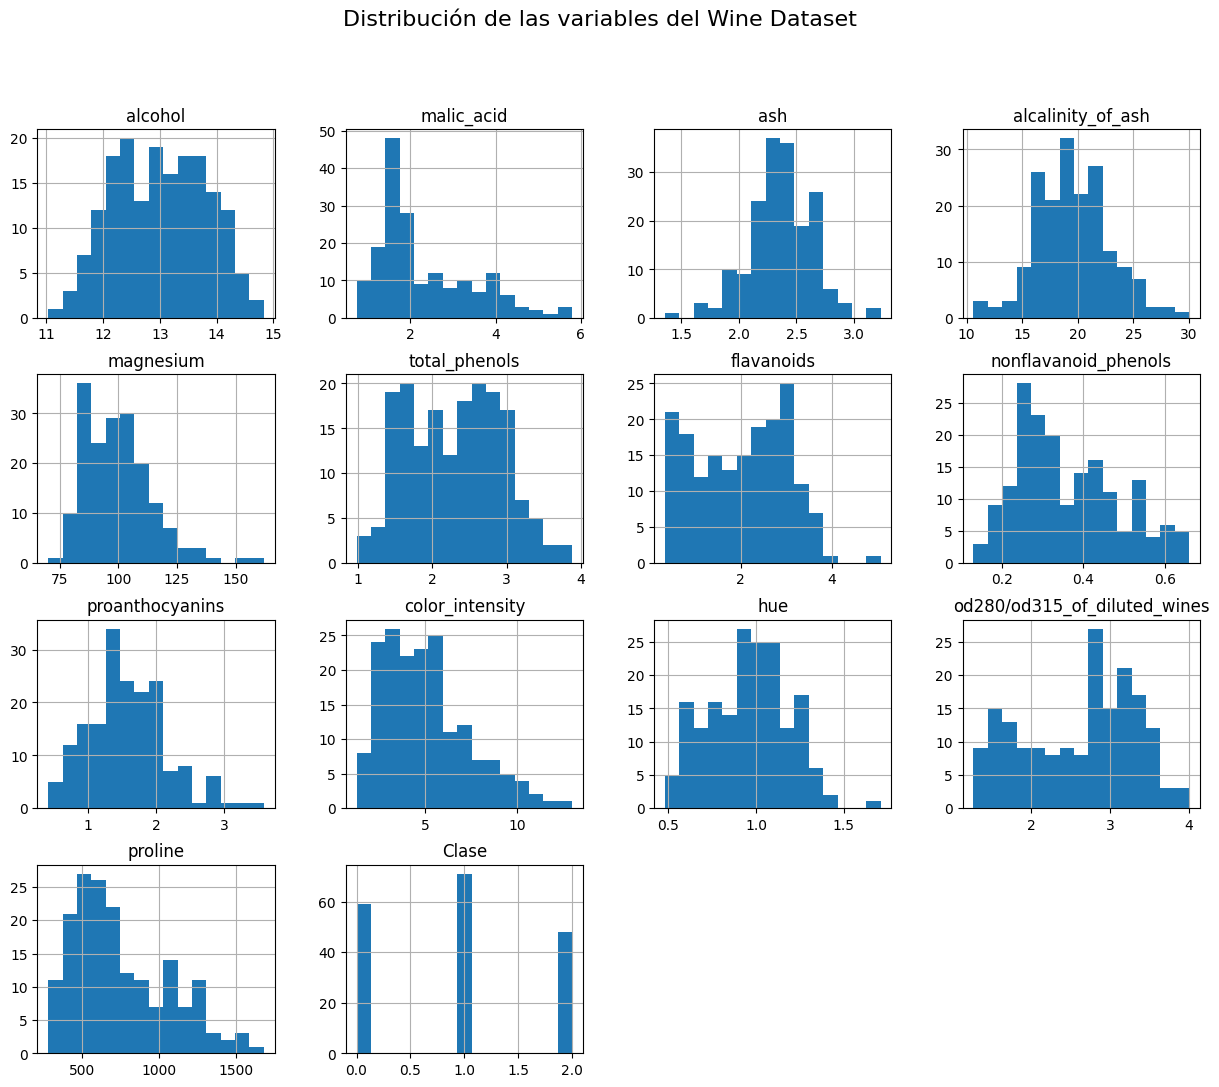

In [12]:
# HISTOGRAMAS

df.hist(figsize=(15,12), bins=15)
plt.suptitle("Distribución de las variables del Wine Dataset", fontsize=16)
plt.show()



**breve interpretación:**

Al observar los histogramas, se puede notar cómo se distribuyen los valores de cada una de las variables del Wine Dataset en donde algunas variables presentan una distribución bastante uniforme, mientras que otras muestran una mayor concentración de datos en determinados rangos. También es evidente que no todas manejan la misma escala; por ejemplo, la variable **Proline** tiene valores mucho más altos que las demás.

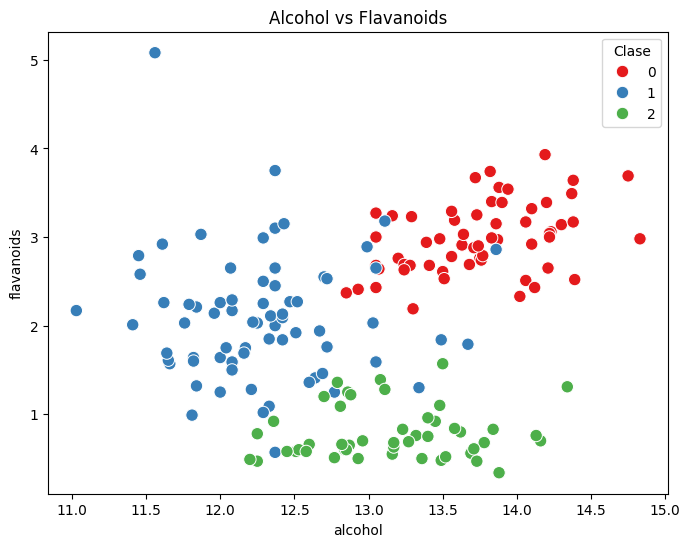

In [13]:
# DIAGRAMA DE DISPERSIÓN

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="alcohol",
    y="flavanoids",
    hue="Clase",
    palette="Set1",
    s=80
)

plt.title("Alcohol vs Flavanoids")

plt.show()

**breve interpretación:**

El diagrama de dispersión muestra la relación entre las variables Alcohol y Flavanoids diferenciando las observaciones según su clase. Se aprecia que existe una separación parcial entre los grupos, aunque también hay zonas donde las clases se superponen.

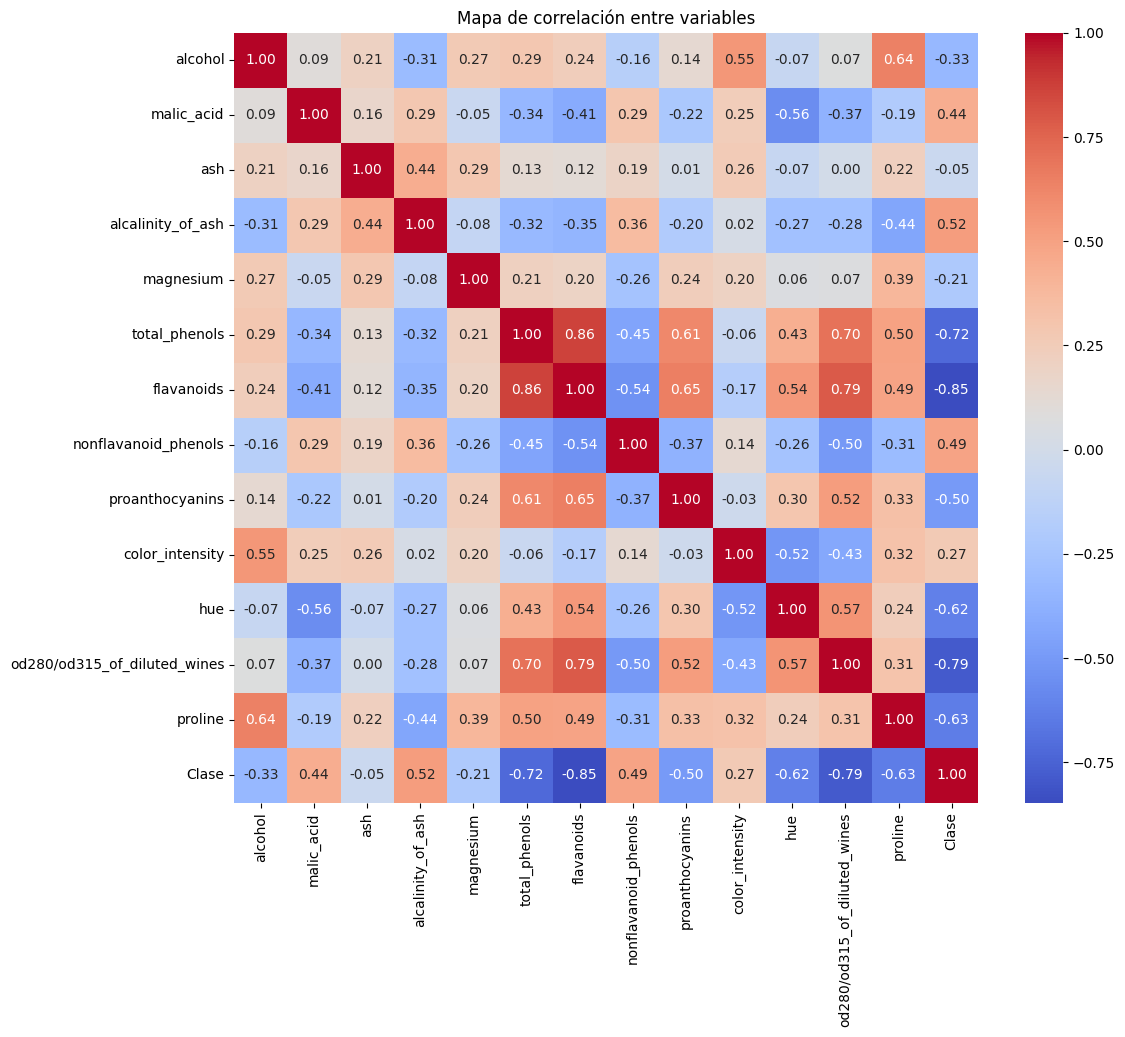

In [14]:
# MAPA DE CORRELACIÓN

plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Mapa de correlación entre variables")

plt.show()

**breve interpretación:**

El mapa de correlación permite identificar el grado de relación lineal entre las variables del conjunto de datos. Se observan correlaciones positivas y negativas de distinta intensidad en la cual se ve que en algunas variables químicas presentan una fuerte relación positiva, mientras que otras muestran correlaciones negativas.


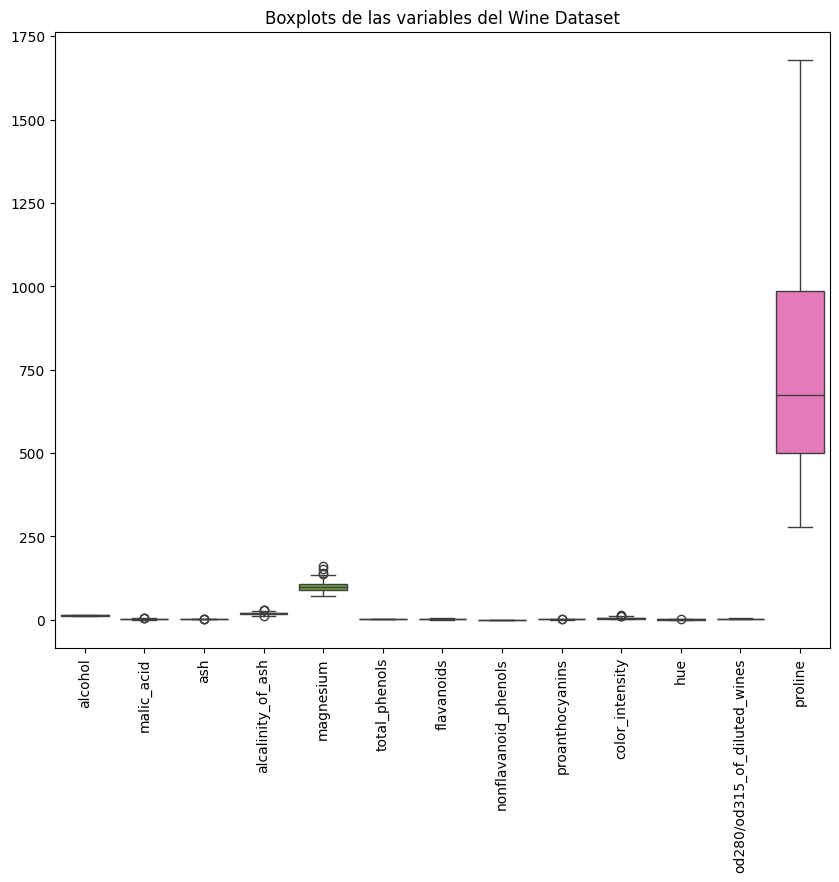

In [15]:
# BOXPLOTS

plt.figure(figsize=(10,8))

sns.boxplot(data=df.drop("Clase", axis=1))

plt.xticks(rotation=90)

plt.title("Boxplots de las variables del Wine Dataset")

plt.show()

**breve interpretación:**

Al analizar el boxplots se puede observar cómo se distribuyen los datos de cada variable y qué tan dispersos se encuentran. También se identifican algunos valores que se alejan del resto, especialmente en la variable Proline, lo que indica la presencia de posibles valores atípicos.


# **4. Preparación de los datos**

Documente las actividades realizadas antes del entrenamiento del modelo, tales como:

separación entre entrenamiento y prueba;

normalización o estandarización (si corresponde);

justificación de las decisiones adoptadas.

In [16]:
# separación entre entrenamiento y prueba.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (142, 13)
Prueba: (36, 13)


In [17]:
#normalización o estandarización (si corresponde)

No se aplicó ningún tratamiento adicional a los datos por que como dice en la actividad establece explícitamente trabajar con el Wine Dataset en su estado original.

# **5. Implementación de LDA**
Entrene un modelo utilizando LinearDiscriminantAnalysis e incluya:

explicación de los parámetros utilizados;

predicciones;

matriz de confusión;

accuracy;

precisión;

recall;

F1-score;

interpretación de los resultados.

In [18]:
# ENTRENAMIENTO DEL MODELO LDA

lda = LinearDiscriminantAnalysis()

lda.fit(X_train, y_train)

LinearDiscriminantAnalysis()

Para entrenar el modelo se utilizó la clase QuadraticDiscriminantAnalysis de la biblioteca scikit-learn  y en este caso no fue necesario realizar modificaciones en los parámetros, por lo que se trabajó con la configuración predeterminada del algoritmo en donde el modelo se entrenó utilizando los datos de entrenamiento mediante el método fit(), permitiendo que aprendiera los patrones y características de cada clase para realizar la clasificación.


In [19]:
# PREDICCIONES

y_pred_lda = lda.predict(X_test)

print(y_pred_lda)

[0 0 2 0 1 0 1 2 1 2 0 2 0 1 0 1 1 1 0 1 0 1 1 2 2 2 1 1 1 0 0 1 2 0 0 0]


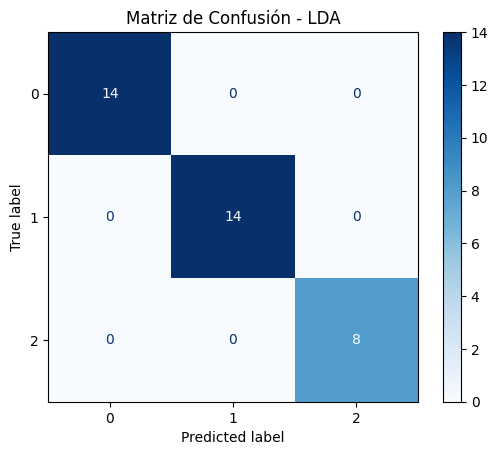

In [20]:
# MATRIZ DE CONFUSIÓN

cm_lda = confusion_matrix(y_test, y_pred_lda)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lda
)

disp.plot(cmap="Blues")

plt.title("Matriz de Confusión - LDA")

plt.show()

In [21]:
# ACCURACY

accuracy_lda = accuracy_score(y_test, y_pred_lda)

print("Accuracy:", accuracy_lda)

Accuracy: 1.0


In [22]:
# MÉTRICAS DE EVALUACIÓN LDA

precision_lda = precision_score(y_test, y_pred_lda, average='weighted')
recall_lda = recall_score(y_test, y_pred_lda, average='weighted')
f1_lda = f1_score(y_test, y_pred_lda, average='weighted')

print(f"Accuracy LDA: {accuracy_lda:.4f}")
print(f"Precision LDA: {precision_lda:.4f}")
print(f"Recall LDA: {recall_lda:.4f}")
print(f"F1-Score LDA: {f1_lda:.4f}")

# REPORTE DE CLASIFICACIÓN
print("\nReporte de Clasificación LDA:")

print(classification_report(y_test, y_pred_lda))


Accuracy LDA: 1.0000
Precision LDA: 1.0000
Recall LDA: 1.0000
F1-Score LDA: 1.0000

Reporte de Clasificación LDA:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



**Interpretación**:

De acuerdo con los resultados obtenidos el modelo **LDA** presentó un excelente desempeño al clasificar las muestras del Wine Dataset. Al observar la matriz de confusión, se puede apreciar que todas las observaciones del conjunto de prueba fueron clasificadas correctamente, ya que no se registraron errores entre las tres clases y asimismo, el modelo alcanzó un **Accuracy de 1.00 (100 %)**, lo que indica que logró predecir correctamente todas las muestras evaluadas. De igual manera, las métricas de **Precision**, **Recall** y **F1-score** también obtuvieron un valor de **1.00** para cada una de las clases, demostrando que el modelo identificó correctamente todos los tipos de vino y mantuvo un rendimiento muy alto durante la clasificación y ademas estos resultados muestran que el modelo LDA se adapta muy bien al Wine Dataset, ya que fue capaz de clasificar correctamente todas las muestras utilizando los datos originales, sin necesidad de aplicar procesos de normalización o algún otro tratamiento previo.


# **6. Implementación de QDA**

Repita el procedimiento utilizando QuadraticDiscriminantAnalysis, explicando los parámetros seleccionados e interpretando los resultados obtenidos.

In [23]:
# ENTRENAMIENTO DEL MODELO QDA

qda = QuadraticDiscriminantAnalysis()

qda.fit(X_train, y_train)

QuadraticDiscriminantAnalysis()

Para entrenar el modelo se utilizó la clase QuadraticDiscriminantAnalysis de la biblioteca scikit-learn. En este caso no se modificó ningún parámetro, por lo que el algoritmo trabajó con su configuración predeterminada

In [24]:
# PREDICCIONES QDA

y_pred_qda = qda.predict(X_test)

print(y_pred_qda)

[0 0 2 0 1 0 1 2 1 2 0 2 0 1 0 1 1 1 0 1 0 1 1 2 2 2 1 1 1 0 0 1 1 0 0 0]


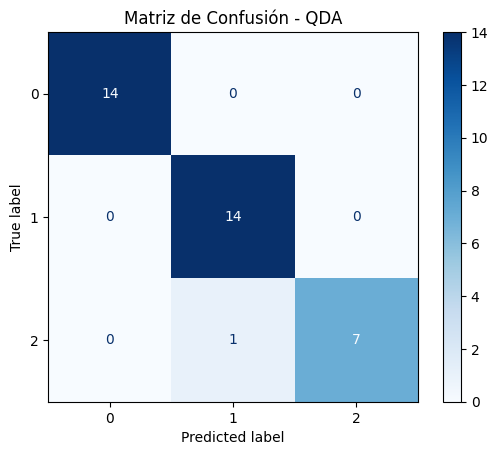

In [25]:
# MATRIZ DE CONFUSIÓN QDA

cm_qda = confusion_matrix(y_test, y_pred_qda)

disp_qda = ConfusionMatrixDisplay(
    confusion_matrix=cm_qda
)

disp_qda.plot(cmap="Blues")

plt.title("Matriz de Confusión - QDA")

plt.show()

In [26]:
# MÉTRICAS DE EVALUACIÓN QDA

accuracy_qda = accuracy_score(y_test, y_pred_qda)
precision_qda = precision_score(y_test, y_pred_qda, average='weighted')
recall_qda = recall_score(y_test, y_pred_qda, average='weighted')
f1_qda = f1_score(y_test, y_pred_qda, average='weighted')

print(f"Accuracy QDA: {accuracy_qda:.4f}")
print(f"Precision QDA: {precision_qda:.4f}")
print(f"Recall QDA: {recall_qda:.4f}")
print(f"F1-Score QDA: {f1_qda:.4f}")

print("\nReporte de Clasificación QDA:")
print(classification_report(y_test, y_pred_qda))

Accuracy QDA: 0.9722
Precision QDA: 0.9741
Recall QDA: 0.9722
F1-Score QDA: 0.9718

Reporte de Clasificación QDA:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36



## **Interpretación**:

De acuerdo con los resultados obtenidos, el modelo QDA presentó un muy buen desempeño en la clasificación del Wine Dataset en donde la mayoría de las muestras fueron clasificadas correctamente, con un Accuracy de 97.22 %, aunque se registró un pequeño error en una de las clases y además las métricas de precisión, recall y F1-score muestran un rendimiento alto y equilibrado.


# **7. Comparación de modelos**

Compare ambos modelos considerando:

desempeño predictivo;

matriz de confusión;

métricas de evaluación;

tiempo de entrenamiento (opcional);

ventajas y limitaciones observadas.

In [27]:
# COMPARACIÓN DE DESEMPEÑO PREDICTIVO Y METRICAS DE EVALUACION

comparacion = pd.DataFrame({
    "Modelo": ["LDA", "QDA"],
    "Accuracy": [accuracy_lda, accuracy_qda],
    "Precision": [
        precision_score(y_test, y_pred_lda, average="weighted"),
        precision_score(y_test, y_pred_qda, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred_lda, average="weighted"),
        recall_score(y_test, y_pred_qda, average="weighted")
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lda, average="weighted"),
        f1_score(y_test, y_pred_qda, average="weighted")
    ]
})

comparacion

,Modelo,Accuracy,Precision,Recall,F1-score
0,LDA,1.000000,1.000000,1.000000,1.000000
1,QDA,0.972222,0.974074,0.972222,0.971775


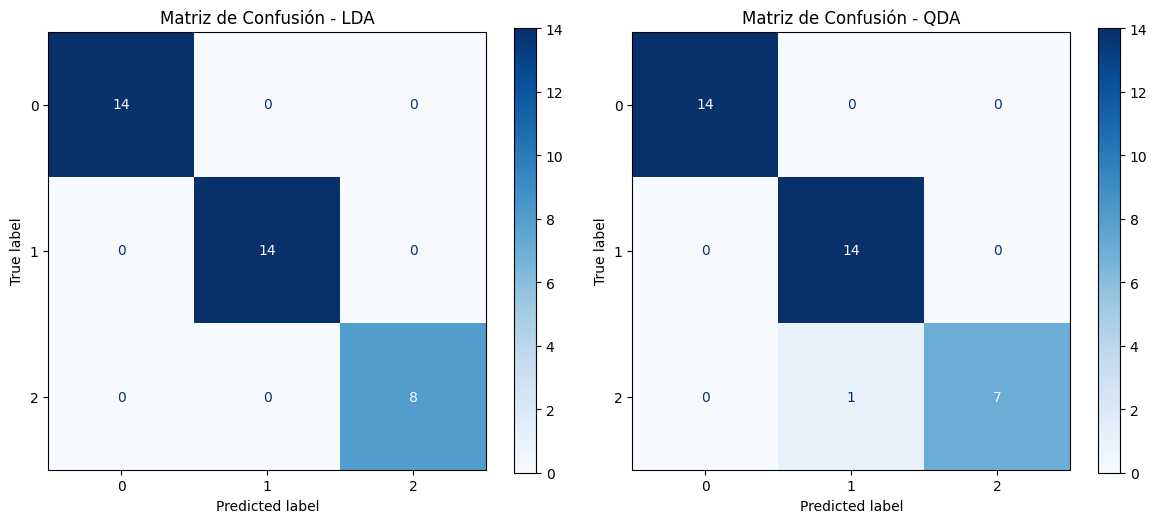

In [28]:
# COMPARACIÓN DE LAS MATRICES DE CONFUSION DE LDA Y QDA
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de Confusión LDA
disp_lda = ConfusionMatrixDisplay(confusion_matrix=cm_lda, display_labels=lda.classes_)
disp_lda.plot(cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión - LDA')

# Matriz de Confusión QDA
disp_qda = ConfusionMatrixDisplay(confusion_matrix=cm_qda, display_labels=qda.classes_)
disp_qda.plot(cmap='Blues', ax=axes[1])
axes[1].set_title('Matriz de Confusión - QDA')

plt.tight_layout()
plt.show()

In [29]:
import time

# Tiempo de entrenamiento para LDA
start_time_lda = time.time()
lda.fit(X_train, y_train)
end_time_lda = time.time()
training_time_lda = end_time_lda - start_time_lda

# Tiempo de entrenamiento para QDA
start_time_qda = time.time()
qda.fit(X_train, y_train)
end_time_qda = time.time()
training_time_qda = end_time_qda - start_time_qda

print(f"Tiempo de entrenamiento LDA: {training_time_lda:.4f} segundos")
print(f"Tiempo de entrenamiento QDA: {training_time_qda:.4f} segundos")

Tiempo de entrenamiento LDA: 0.0051 segundos
Tiempo de entrenamiento QDA: 0.0076 segundos


# **ventajas y limitaciones observadas:**


Mediante las comparaciones observadas entre los modelos LDA y QDA, pude identificar que ambos presentaron un buen desempeño al clasificar los datos pero sin embargo, LDA obtuvo mejores resultados en este caso, entre sus principales ventajas se encuentra su alta capacidad de clasificación, ya que logró identificar correctamente todas las muestras evaluadas, además de presentar un tiempo de entrenamiento muy rápido y una estructura más simple. Por otro lado, QDA también mostró un rendimiento alto y una ventaja importante es su flexibilidad, debido a que permite trabajar con una matriz de covarianza diferente para cada clase, lo que puede ser útil cuando los datos presentan relaciones más complejas.

En cuanto a las limitaciones, LDA depende de ciertas condiciones en los datos, como asumir que las clases poseen características similares, por lo que si estas no se cumplen su rendimiento podría verse afectado. En el caso de QDA, aunque obtuvo resultados muy buenos, presentó un pequeño error de clasificación y, al manejar una mayor cantidad de parámetros, puede volverse más complejo y aumentar el riesgo de sobreajuste en algunos casos.


# **8. Fronteras de decisión**
Utilice dos variables del conjunto de datos para representar gráficamente las fronteras de decisión generadas por LDA y QDA.

Analice las diferencias observadas entre ambos modelos.

In [30]:
# SELECCIÓN DE DOS VARIABLES

X2 = df[["alcohol", "flavanoids"]]

y = df["Clase"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2,y,test_size=0.2,random_state=42)

lda2 = LinearDiscriminantAnalysis()
qda2 = QuadraticDiscriminantAnalysis()

lda2.fit(X_train2, y_train2)
qda2.fit(X_train2, y_train2)

QuadraticDiscriminantAnalysis()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuadraticDiscriminantAnalysis was fitted with feature names
  warnings.warn(


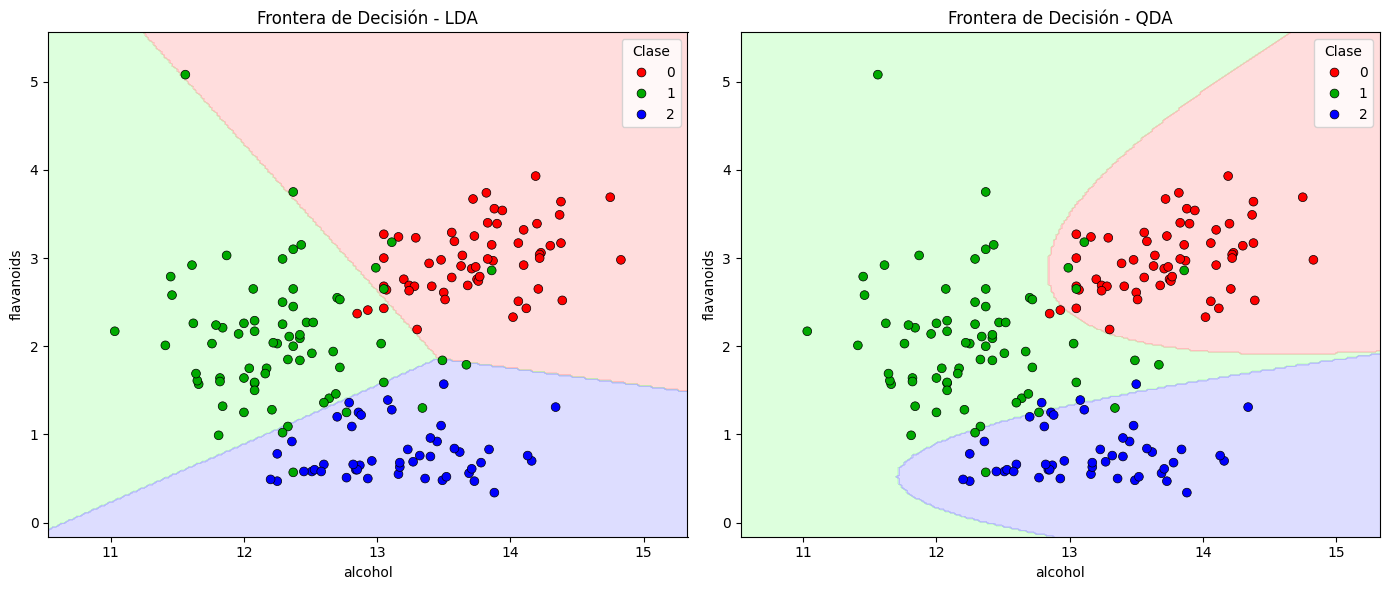

In [31]:
# FRONTERA DE DESCISIÓN
def plot_decision_boundary(X, y, model, ax, title):

    # Límites de la gráfica
    x_min, x_max = X.iloc[:, 0].min() - 0.5, X.iloc[:, 0].max() + 0.5
    y_min, y_max = X.iloc[:, 1].min() - 0.5, X.iloc[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),np.arange(y_min, y_max, 0.02))

    # Predicciones
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Colores
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00AA00', '#0000FF'])

    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.4)

    # Dibujar puntos
    sns.scatterplot(x=X.iloc[:, 0],y=X.iloc[:, 1],hue=y,palette=cmap_bold.colors,s=40,edgecolor='k',ax=ax,legend=True)

    ax.set_title(title)
    ax.set_xlabel(X.columns[0])
    ax.set_ylabel(X.columns[1])


# VISUALIZACIÓN

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_decision_boundary(X2,y,lda2,axes[0],"Frontera de Decisión - LDA")

plot_decision_boundary(X2,y,qda2,axes[1],"Frontera de Decisión - QDA")

plt.tight_layout()
plt.show()

# **Analice las diferencias observadas entre ambos modelos.**

Las fronteras de decisión generadas por LDA son líneas rectas, reflejando su naturaleza lineal en la cual esto se debe a que LDA asume que las clases tienen la misma matriz de covarianza, resultando en límites de decisión lineales y por otro lado la QDA muestra fronteras de decisión curvas ya que esto es porque QDA permite que cada clase tenga su propia matriz de covarianza, lo que le da mayor flexibilidad para modelar relaciones más complejas entre las características y por lo tanto genera límites de decisión cuadráticos.


# **9. Conclusiones**
Presente al menos cinco conclusiones fundamentadas relacionadas con:

el comportamiento de LDA

el comportamiento de QDA;

influencia de los supuestos estadísticos;

comparación de resultados;

aplicaciones prácticas.

**el comportamiento de LDA:**

 Se observó que el modelo LDA presentó un excelente desempeño en la clasificación del Wine Dataset, alcanzando un Accuracy del 100 %. Además, clasificó correctamente todas las muestras del conjunto de prueba, lo que demuestra que este modelo se ajustó adecuadamente a las características presentes en los datos.



**el comportamiento de QDA:**

El modelo QDA también presentó un rendimiento muy alto, alcanzando un Accuracy del 97.22 %. Aunque se registró un pequeño error en la clasificación de una muestra, las métricas de Precision, Recall y F1-score muestran que sigue siendo un modelo confiable .


**influencia de los supuestos estadísticos:**

Los resultados obtenidos permiten observar que los supuestos estadísticos influyen directamente en el desempeño de los modelos y en este caso, la hipótesis de que las clases comparten una misma matriz de covarianza favoreció a LDA, permitiéndole obtener mejores resultados que QDA en el Wine Dataset.


**comparación de resultados:**

La comparación entre ambos modelos permitió observar que aunque QDA tiene una mayor flexibilidad al generar fronteras de decisión curvas, esta característica no aportó una mejora significativa en este conjunto de datos pero en cambio, las fronteras lineales de LDA fueron suficientes para separar correctamente las tres clases y obtener una clasificación perfecta.



**aplicaciones prácticas:**

esta práctica permitió comprender que tanto LDA como QDA son modelos útiles para resolver problemas de clasificación supervisada. Sin embargo pienso que la la elección del modelo depende de las características de los datos y de qué tan bien se ajusten a las condiciones de cada método, pero concluyo que en este caso la LDA resultó ser la mejor opción para el Wine Dataset, ya que presentó una mayor precisión y un mejor desempeño general.

